In [1]:
# Standard library imports
import os
import sys
import warnings
import textwrap
import string
from pathlib import Path
from typing import Dict, Tuple, Optional

# Third-party imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
)

import xgboost as xgb
from matplotlib.patches import Rectangle, Patch

# Silence warnings
warnings.filterwarnings("ignore")

# Add project paths
cwd = Path.cwd()
sys.path.insert(0, str(cwd))
sys.path.append(str(cwd.parent))

# Project imports
from bin.gaussian_process import *
from bin.evaluate_memory_allocation_methods import HPCMemoryEvaluator, WeightingConfig
import bin.evaluate_memory_allocation_methods
from bin.evaluation_metrics import JobCost

import argparse

# Evaluating resource allocation models for assembly HPC jobs

Accurately predicting resource use is essential in shared HPC systems. When memory estimates are off, throughput of a pipeline is limited or results in waste resources. Choosing the right model requires evaluation methods that reflect how systems actually run.

From a user’s view, a failed job means lost time and job caring. From an HPC administrator’s view, it means resource duplication when the system retries. Both translate into wasted compute.

In this analysis, we tested several models and evaluation metrics to understand which approach best supports real-world HPC workloads.

---

## Standard metrics tell only part of the story

We started with the usual indicators — MAE, RMSE, and R² — and included a safety/efficiency trade-off metric.

At first, the Random Forest model looked best. It achieved the lowest error and offered a good balance between under- and over-prediction.

In [2]:
stats_file = "../results/updated_mgnify_assemblies_stats_v3.15.3_metaspades_kmer10_stats_filesize.csv"
y_file = "../results/updated_mgnify_assemblies_stats_v3.15.3_metaspades_subset.csv"

df = load_your_data(stats_file, y_file)
df = df[df["peak_mem_in_gbs"] <= df["peak_mem_in_gbs"].quantile(0.95)]
df = df[df["file_size"] <= df["file_size"].quantile(0.95)]

stats = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

features_all = stats.columns.tolist()

# MGnify heuristic predictor

In [3]:
### Our current allocation method, add it for comparison
biome_heuristic_table = pd.read_csv("../data/biome_assembler_heurs.tsv",sep="\t")
"""
memory_gb	process	assembler_name	biome_name	biome_lineage
80	ASSEM	flye	root	root
80	ASSEM	megahit	root	root
"""

def our_allocation_method(
        biome_lineage: str,
        process: str = "ASSEM",
        assembler_name: str = "metaspades",
) -> float:
        """
        finds the rows in biome_heuristic_table that match the process and assembler_name params,
        fot biome_lineage finds the most specific match (longest string match)
        returns the memory_gb value for that row
        if no match found, returns 80.0 (default)
        """
        biome_lineage = biome_lineage.lower().replace("-","_").replace(":",".").replace(" ","_")
        new_df = biome_heuristic_table[
                (biome_heuristic_table["process"] == process) &
                (biome_heuristic_table["assembler_name"] == assembler_name)
        ].copy()
        if new_df.empty:
                return 80.0
        # find most specific match for biome_lineage
        new_df["lineage_length"] = new_df["biome_lineage"].apply(len)

        new_df = new_df[new_df["biome_lineage"].apply(lambda x: biome_lineage.startswith(x))]
        if new_df.empty:
                return 80.0
        new_df = new_df.sort_values(by="lineage_length", ascending=False)
        return float(new_df.iloc[0]["memory_gb"])



# Galaxy EU heuristic predictor

In [4]:
def galaxy_metaspades_heuristic(input_size: float) -> Tuple[Optional[int], Optional[int], Optional[str]]:
    """
    Heuristic predictor for Galaxy MetaSPAdes tool.

    Parameters
    ----------
    input_size : float
        Size of the input data in GB.

    Returns
    -------
    cores : int or None
        Number of CPU cores to allocate.
    mem : int or None
        Memory in GB to allocate.
    fail_msg : str or None
        Failure message if input is too large.
    """
    # default values
    mem = None
    input_size = input_size / 1024**3

    if input_size < 1:
        mem = 100
    elif 1 <= input_size:
        mem = 350

    return mem

# Compute Galaxy heuristic allocation
galaxy_allocations = []
for srr, size in zip(df.index, stats["file_size"]):
    try:
        galaxy_allocations.append(galaxy_metaspades_heuristic(size))
    except ValueError:
        galaxy_allocations.append(np.nan)  # mark as invalid



In [5]:
quant_results = {}

## find the lineage of each sample in traing dataset
mgnify_dataset = pd.read_csv("../data/mgnify_assemblies_stats.csv")
link_df = pd.read_csv("../results/updated_mgnify_assemblies_stats_v3.15.3_metaspades_subset.csv")
err_to_erz = dict(zip(link_df["srr_id"], link_df["primary_accession"]))
erz_to_biome = dict(zip(mgnify_dataset["primary_accession"], mgnify_dataset["lineage"]))
training_df_biomes = [erz_to_biome.get(err_to_erz.get(srr,""),"root") for srr in df.index]
heuristics_memory_allocation = [our_allocation_method(biome_lineage=bl) for bl in training_df_biomes]

# add heuristics
quant_results[("MGnify Heuristic","default")] = np.array(heuristics_memory_allocation)
quant_results[("Galaxy Heuristic", "default")] = np.array(galaxy_allocations)

In [6]:
## Train a model that takes into account the biome
trimmed_biomes = [":".join(x.split(":")[:3]) if "Engineered" in x else ":".join(x.split(":")[:4]) for x in training_df_biomes]
# encode biome as categorical variable and join with stats

ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
biome_ohe = ohe.fit_transform(np.array(trimmed_biomes).reshape(-1,1))
biome_ohe_df = pd.DataFrame(biome_ohe, index=df.index, columns=[f"biome_{c}" for c in ohe.categories_[0]])
stats_biome = pd.concat([stats, biome_ohe_df], axis=1)
df_biome = pd.concat([df, biome_ohe_df], axis=1)
# stats_biome


# Train models based on kmer stats, kmer stats + File size, kmer stats + File size + biome, biome

In [7]:

# build model list
models = [
    ("Random Forest", RandomForestRegressor(random_state=42)),
    ("LinearRegression", LinearRegression()),
]

cv = KFold(n_splits=5, shuffle=True, random_state=42)

# quant_results = {}
quantiles = [0.9, 0.99]

for train_idx, test_idx in cv.split(stats, y):
    x_train, y_train = stats.iloc[train_idx], y.iloc[train_idx]
    x_test, y_test = stats.iloc[test_idx], y.iloc[test_idx]

    X_biome_train = biome_ohe_df.iloc[train_idx]
    X_biome_test = biome_ohe_df.iloc[test_idx]

    X_combined_train = stats_biome.iloc[train_idx]   # K-mers + File size + Biome
    X_combined_test = stats_biome.iloc[test_idx]

    for title, base_model in models:
        model = clone(base_model)

        # 1) K-mers + File size  (stats)
        model.fit(x_train, y_train)
        preds = model.predict(x_test)
        quant_results.setdefault(
            (f"{title} (K-mers + File size)", "default"),
            np.empty_like(y)
        )[test_idx] = preds

        # 2) File size only
        model = clone(base_model)
        model.fit(x_train[["file_size"]], y_train)
        preds = model.predict(x_test[["file_size"]])
        quant_results.setdefault(
            (f"{title} (File size)", "default"),
            np.empty_like(y)
        )[test_idx] = preds

        # 3) K-mers + File size + Biome
        model = clone(base_model)
        model.fit(X_combined_train, y_train)
        preds = model.predict(X_combined_test)
        quant_results.setdefault(
            (f"{title} (K-mers + File size + Biome)", "default"),
            np.empty_like(y)
        )[test_idx] = preds

        # 4) Biome only
        model = clone(base_model)
        model.fit(X_biome_train, y_train)
        preds = model.predict(X_biome_test)
        quant_results.setdefault(
            (f"{title} (Biome)", "default"),
            np.empty_like(y)
        )[test_idx] = preds

    # =========================================================
    # ---------------- Gaussian Processes ----------------------
    # =========================================================

    # Prepare GP training DataFrames (must contain TARGET_COL)
    df_kmer = df.iloc[train_idx]                       # K-mers + file size
    df_file = df.iloc[train_idx][["file_size", TARGET_COL]]
    df_biome_only = biome_ohe_df.iloc[train_idx].copy()          # Biome only
    df_biome_only[TARGET_COL] = y_train.values
    df_combined = stats_biome.iloc[train_idx].copy()
    df_combined[TARGET_COL] = y_train.values

    # Train GP models
    gp_kmer = train_and_save(df_kmer, out_path=None, log_target=False)
    gp_file = train_and_save(df_file, out_path=None, log_target=False)
    gp_biome = train_and_save(df_biome_only, out_path=None, log_target=False)
    gp_combined = train_and_save(df_combined, out_path=None, log_target=False)

    # Validation features (drop target!)
    X_kmer_val = df.iloc[test_idx].drop(columns=[TARGET_COL])
    X_file_val = X_kmer_val[["file_size"]]
    X_biome_val = df_biome.iloc[test_idx].drop(columns=[TARGET_COL])
    X_combined_val = stats_biome.iloc[test_idx]

    for q in quantiles:

        # 1) K-mers + File size
        y_q = gp_kmer.predict_quantile(X_kmer_val, q=q)
        quant_results.setdefault(
            ("Gaussian Processes (K-mers + File size)", q),
            np.empty_like(y)
        )[test_idx] = y_q

        # 2) File size only
        y_q = gp_file.predict_quantile(X_file_val, q=q)
        quant_results.setdefault(
            ("Gaussian Processes (File size)", q),
            np.empty_like(y)
        )[test_idx] = y_q

        # 3) Biome only
        y_q = gp_biome.predict_quantile(X_biome_val, q=q)
        quant_results.setdefault(
            ("Gaussian Processes (Biome)", q),
            np.empty_like(y)
        )[test_idx] = y_q

        # 4) K-mers + File size + Biome
        y_q = gp_combined.predict_quantile(X_combined_val, q=q)
        quant_results.setdefault(
            ("Gaussian Processes (K-mers + File size + Biome)", q),
            np.empty_like(y)
        )[test_idx] = y_q

        

In [8]:
for k in quant_results.keys():
    print(k)

('MGnify Heuristic', 'default')
('Galaxy Heuristic', 'default')
('Random Forest (K-mers + File size)', 'default')
('Random Forest (File size)', 'default')
('Random Forest (K-mers + File size + Biome)', 'default')
('Random Forest (Biome)', 'default')
('LinearRegression (K-mers + File size)', 'default')
('LinearRegression (File size)', 'default')
('LinearRegression (K-mers + File size + Biome)', 'default')
('LinearRegression (Biome)', 'default')
('Gaussian Processes (K-mers + File size)', 0.9)
('Gaussian Processes (File size)', 0.9)
('Gaussian Processes (Biome)', 0.9)
('Gaussian Processes (K-mers + File size + Biome)', 0.9)
('Gaussian Processes (K-mers + File size)', 0.99)
('Gaussian Processes (File size)', 0.99)
('Gaussian Processes (Biome)', 0.99)
('Gaussian Processes (K-mers + File size + Biome)', 0.99)


In [36]:
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score
import re

# -----------------------------
# Extract components cleanly
# -----------------------------
def parse_name(name):
    """
    Expected patterns like:
    'Random Forest (K-mers + File size + Biome) 0.9'
    'Gaussian Processes (File size) 0.99'
    """

    # Extract quantile if present
    quantile_match = re.search(r"(0\.\d+)", name)
    quantile = quantile_match.group(1) if quantile_match else "-"

    # Remove quantile
    name_no_q = re.sub(r"\s0\.\d+", "", name)

    # Extract model name (before first bracket)
    model = name_no_q.split("(")[0].strip()

    # Extract features inside parentheses
    feature_match = re.search(r"\((.*?)\)", name_no_q)
    features = feature_match.group(1) if feature_match else "Heuristic"

    return model, features, quantile


# -----------------------------
# Compute metrics
# -----------------------------
results_list = []

for key, preds in quant_results.items():

    raw_name = f"{key[0]} {key[1]}"

    model, features, quantile = parse_name(raw_name)

    r2 = r2_score(y, preds)
    rmse = np.sqrt(np.mean((y - preds) ** 2))

    results_list.append({
        "raw_name":raw_name,
        "Model": model,
        "Features": features,
        "Quantile": quantile,
        "R²": r2,
        "RMSE": rmse
    })

# -----------------------------
# Build DataFrame
# -----------------------------
df_results = pd.DataFrame(results_list)

# Sort by R²
df_results = df_results.sort_values(by="R²", ascending=False).reset_index(drop=True)

# -----------------------------
# Output
# -----------------------------
print(df_results.to_markdown(index=False))

# Save table
df_results.to_csv("../results/model_performance.csv", index=False)

| raw_name                                              | Model                    | Features                   | Quantile   |          R² |     RMSE |
|:------------------------------------------------------|:-------------------------|:---------------------------|:-----------|------------:|---------:|
| Random Forest (K-mers + File size + Biome) default    | Random Forest            | K-mers + File size + Biome | -          |   0.678518  |  31.0461 |
| Random Forest (K-mers + File size) default            | Random Forest            | K-mers + File size         | -          |   0.64876   |  32.4512 |
| Random Forest (Biome) default                         | Random Forest            | Biome                      | -          |   0.466952  |  39.9771 |
| LinearRegression (Biome) default                      | LinearRegression         | Biome                      | -          |   0.465481  |  40.0322 |
| Gaussian Processes (Biome) 0.9                        | Gaussian Processes       | Bio

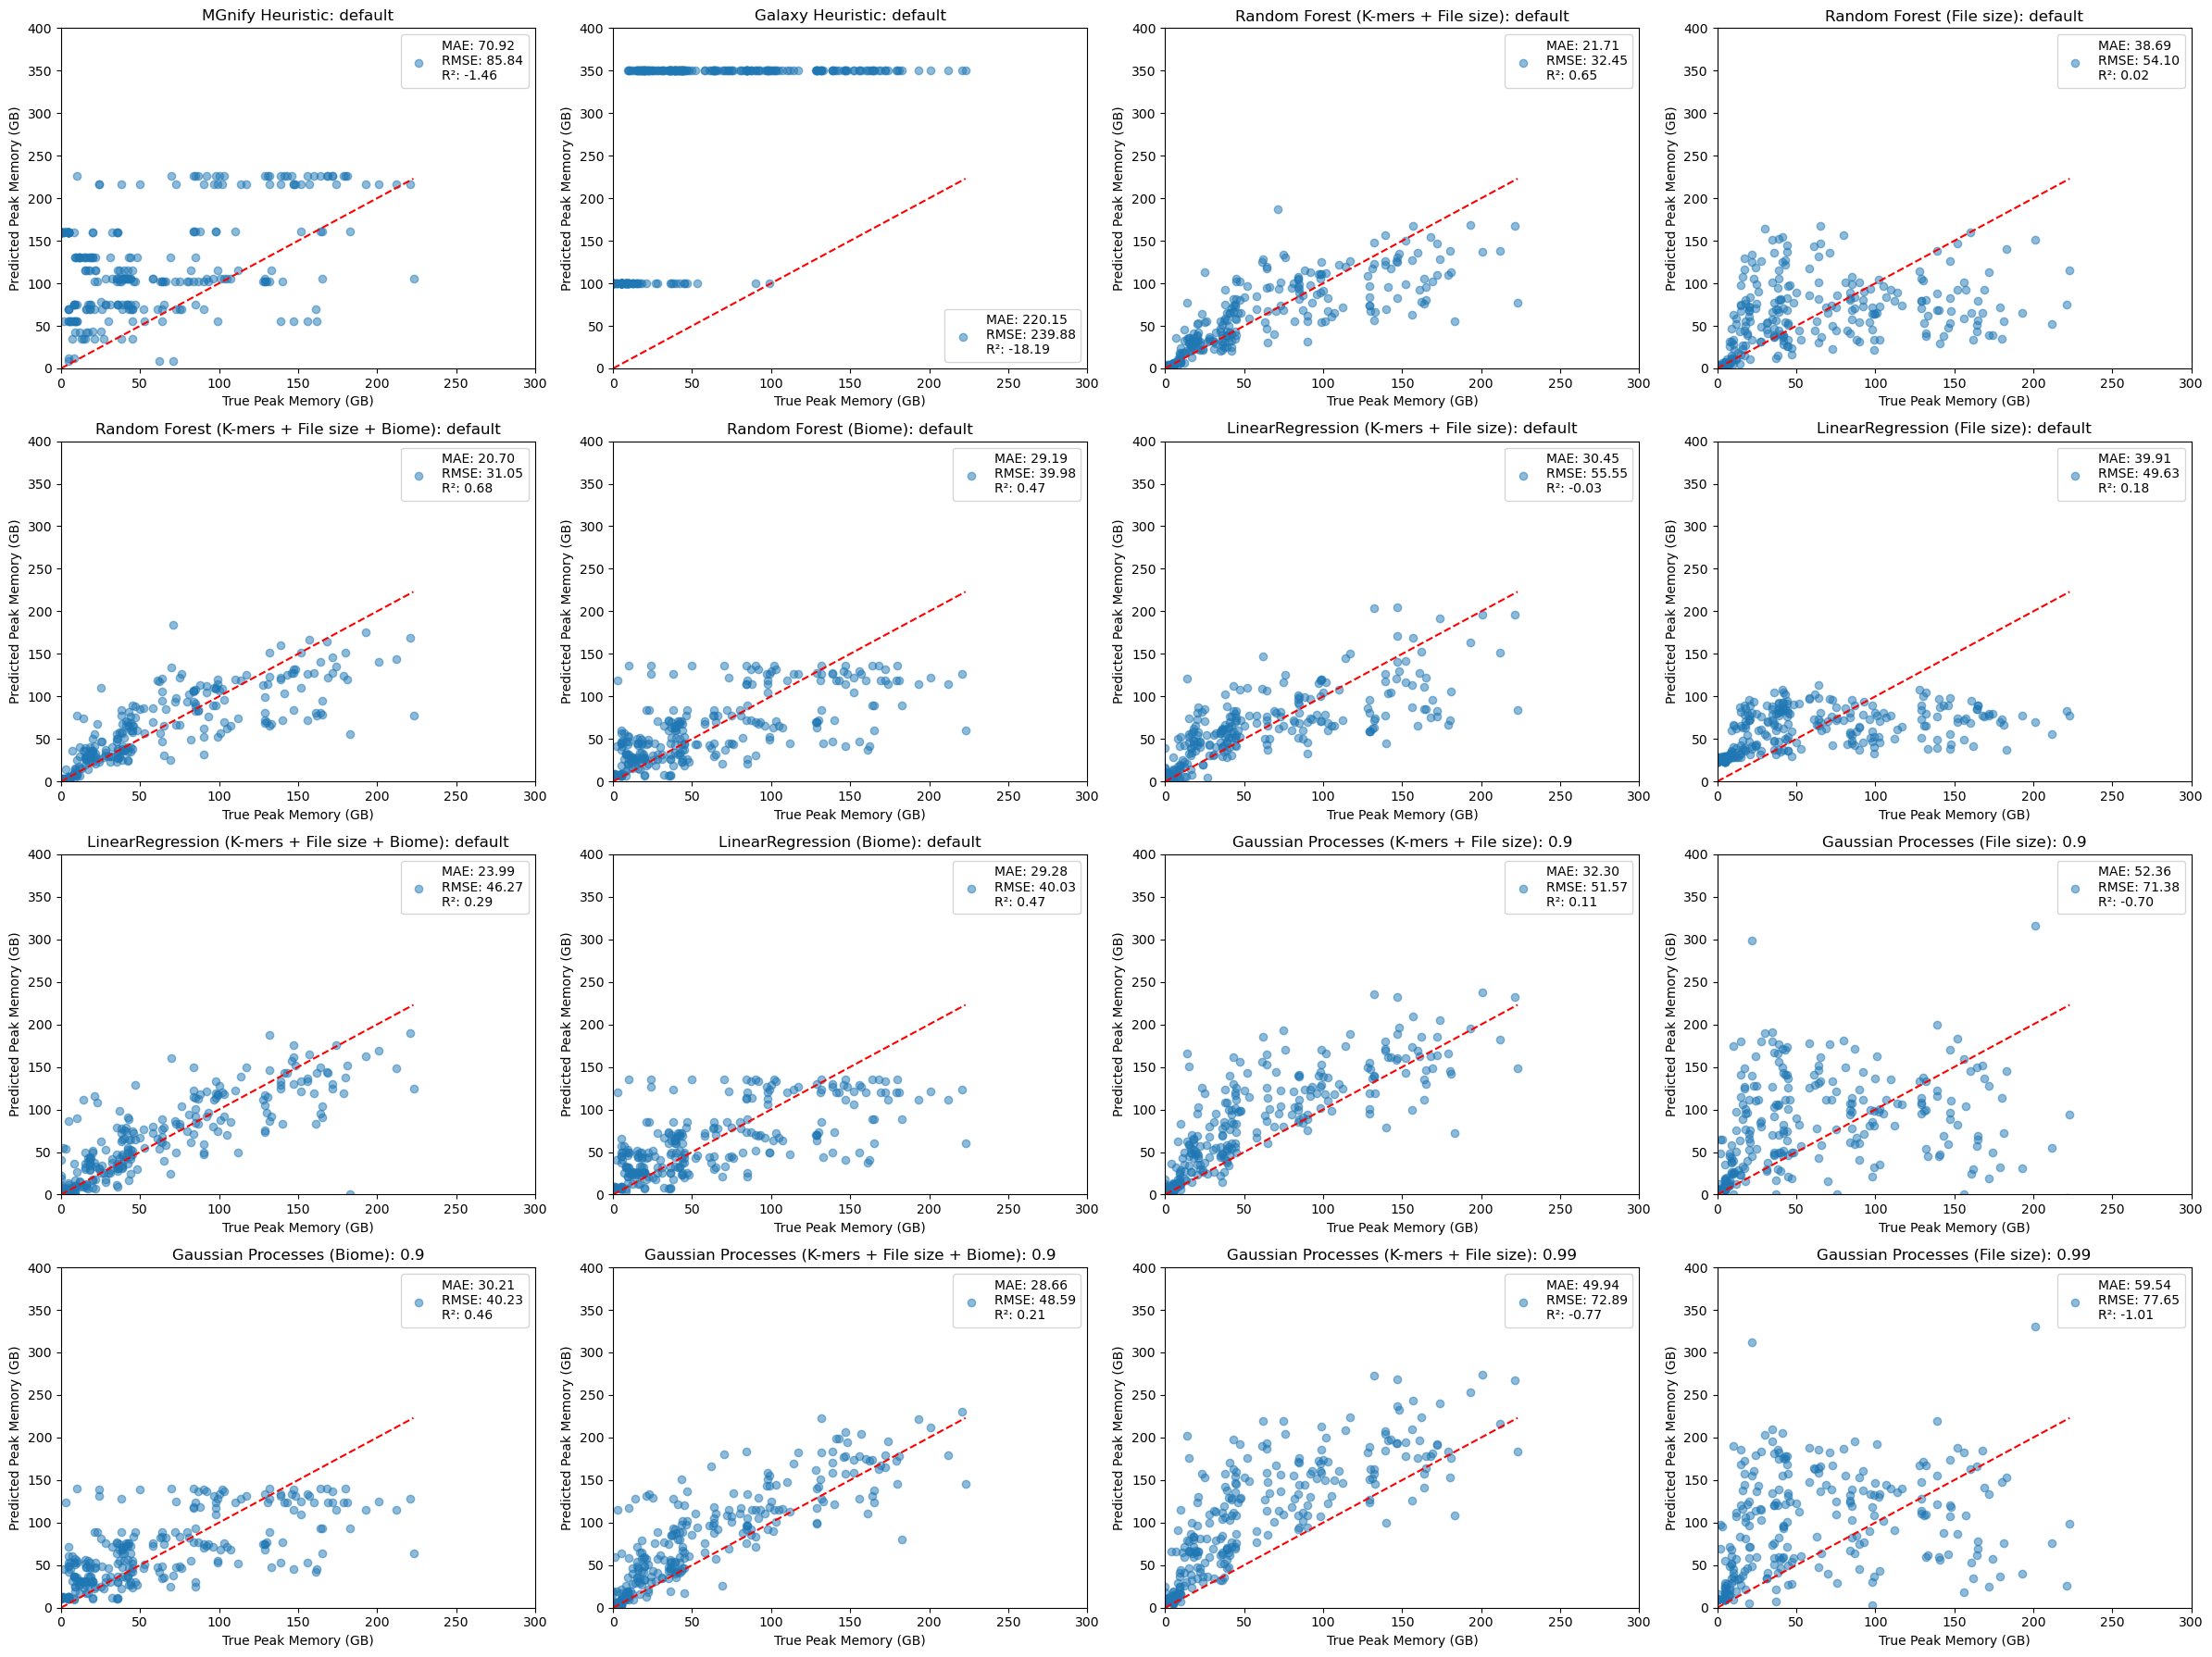

In [10]:
# 3 subplots with scatterplots of predictions vs true. where true = list(y) and pred = quant_results[keys]. The keys I want are [("Random Forest (All)","default"),("File size (Linear)","default"),("Gaussian Processes",0.9999)] 
# - draw diagonal, 
# - also calculate MAE, RMSE, and R² (show in legend)
plt.rcdefaults()
keys = list(quant_results.keys())

# Create 3x4 grid
fig, axes = plt.subplots(4, 4, figsize=(6*4, 6*3))
axes = axes.flatten()  # flatten to iterate easily

# Plot the predictions
for ax, key in zip(axes, keys):
    preds = quant_results[key]
    ax.scatter(y, preds, alpha=0.5)
    ax.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
    ax.set_title(f"{key[0]}: {key[1]}")
    ax.set_xlabel("True Peak Memory (GB)")
    ax.set_ylabel("Predicted Peak Memory (GB)")
    
    # Metrics
    mae = mean_absolute_error(y, preds)
    rmse = np.sqrt(np.mean((y - preds)**2))  # RMSE
    r2 = r2_score(y, preds)
    ax.legend([f"MAE: {mae:.2f}\nRMSE: {rmse:.2f}\nR²: {r2:.2f}"])
    
    # Set limits
    ax.set_xlim(0, 300)
    ax.set_ylim(0, 400)

# Remove any unused axes if there are fewer keys than 12
for ax in axes[len(keys):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

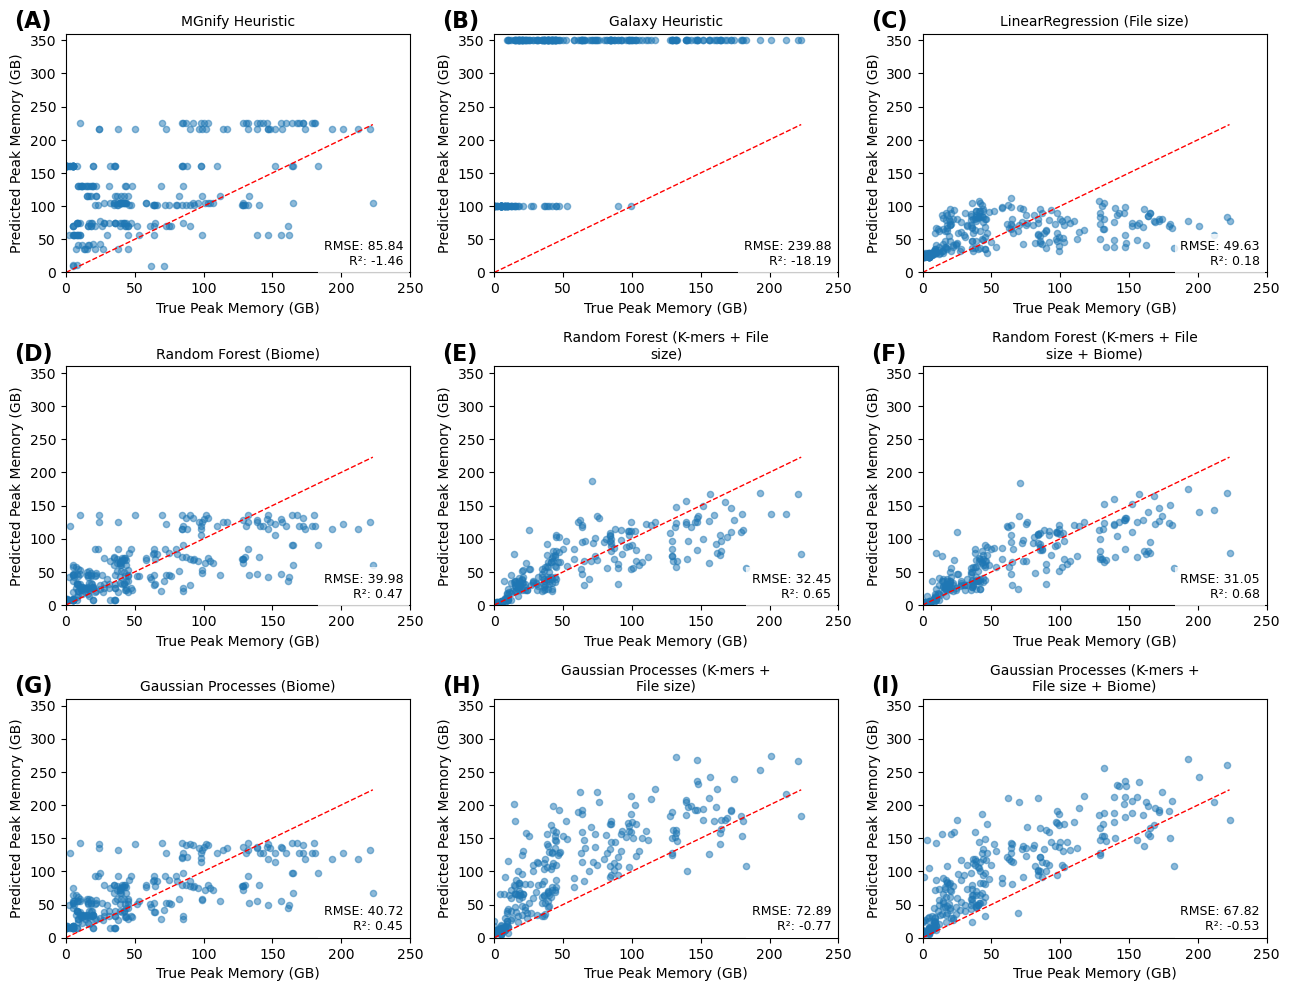

In [63]:
plt.rcdefaults()
import string

# keys = [
#     ('MGnify Heuristic', 'default'),
#     ('Galaxy Heuristic', 'default'),
#     ('LinearRegression (File size)', 'default'),
#     ('Random Forest (K-mers + File size)', 'default'),
#     ("Gaussian Processes (K-mers + File size)", 0.99),
#     ("Gaussian Processes (K-mers + File size + Biome)", 0.99),
# ]

keys = [ ('MGnify Heuristic', 'default'), 
        ('Galaxy Heuristic', 'default'), 
        ('LinearRegression (File size)', 'default'), 
        ('Random Forest (Biome)', 'default'), 
        ('Random Forest (K-mers + File size)', 'default'), 
        ('Random Forest (K-mers + File size + Biome)', 'default'), 
        ("Gaussian Processes (Biome)", 0.99), 
        ("Gaussian Processes (K-mers + File size)", 0.99), 
        ("Gaussian Processes (K-mers + File size + Biome)", 0.99), ]


# Slightly taller for publication proportions
fig, axes = plt.subplots(3, 3, figsize=(13, 10))
axes = axes.flatten()

panel_labels = list(string.ascii_uppercase)

for i, (ax, key) in enumerate(zip(axes, keys)):
    preds = quant_results[key]

    # Scatter
    ax.scatter(y, preds, alpha=0.5, s=20)

    # Subtle diagonal reference
    ax.plot(
        [y.min(), y.max()],
        [y.min(), y.max()],
        linestyle="--",
        linewidth=1,
        color="red",
    )

    # Wrapped title (slightly smaller)
    wrapped_title = "\n".join(textwrap.wrap(key[0], width=28))
    ax.set_title(wrapped_title, fontsize=10)

    # Large panel label (journal style)
    ax.text(
        -0.15, 1.10,
        f"({panel_labels[i]})",
        transform=ax.transAxes,
        fontsize=16,
        fontweight='bold',
        va='top',
        ha='left'
    )

    ax.set_xlabel("True Peak Memory (GB)", fontsize=10)
    ax.set_ylabel("Predicted Peak Memory (GB)", fontsize=10)

    # Metrics
    rmse = np.sqrt(mean_squared_error(y, preds))
    r2 = r2_score(y, preds)
    ax.text(
        0.98, 0.02,
        f"RMSE: {rmse:.2f}\nR²: {r2:.2f}",
        transform=ax.transAxes,
        fontsize=9,
        ha='right',
        va='bottom',
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none')
    )

    ax.set_xlim(0, 250)
    ax.set_ylim(0, 360)

# Remove unused axes if any
for ax in axes[len(keys):]:
    fig.delaxes(ax)

plt.tight_layout()

# High-resolution export
plt.savefig("../results/memory_prediction_comparison.svg", dpi=600, bbox_inches="tight")
plt.savefig("../results/memory_prediction_comparison.png", dpi=600, bbox_inches="tight")
plt.show()

Further analysis showed that all models struggled with high-memory jobs.

Underestimation led to failed jobs, while overestimation wasted memory on smaller ones.

---

## Rethinking what “good” looks like

A better evaluation should reflect the true cost per job, not just error magnitude between the prediction and the true peak memory.

That cost includes wasted allocations, retry attempts, and the duaration of asked allocations.

Considering these factors, we defined a cost function:
$$
C(y; a_0) = 
\underbrace{\sum_{r=0}^{R-1} C_{\text{fail}}(y, a_r)}_{\text{cost of retries}} 
+ 
\underbrace{C_{\text{over}}(y, a_R)}_{\text{waste on the successful attempt}}
$$
Where:
\[
\begin{aligned}
y &:\ \text{true peak memory use} \\
a_0 &:\ \text{initial memory allocation} \\
a_r &:\ \text{allocation on retry } r \\
R &:\ \text{total number of retries until success} \\
a_R &:\ \text{allocation on successful attempt} \\
C_{\text{fail}}(y, a_r) &:\ \text{cost incurred when a job fails due to under-allocation} \\
C_{\text{over}}(y, a_R) &:\ \text{cost incurred from over-allocation on the successful attempt}
\end{aligned}
\]

Using this function we can simulate the total cost of running jobs under different prediction models and allocation strategies.

For example, a model that underpredicts slightly might cause multiple retries — each consuming more total resources than a single, slightly overpredicted allocation.

**High accuracy of peak memory prediction doesn’t guarantee lower waste**.

We visualise this effect when a job’s true memory use is 120 GB, different starting allocations lead to very different total resource costs. Small prediction errors can multiply into large operational waste.

__Figure:__ Illustration of job memory usage over time.  
Each bar shows a single job attempt, where **height** represents memory usage and **width** represents wall time.  
The **total shaded area** corresponds to the overall resource cost until the job completes successfully. **Dark blue** indicates true memory used, while **light blue** shows wasted allocation.


In [12]:
# Example usage

# dummy_policy = lambda R, a0: a0*2**(R)
dummy_policy = lambda R, a0: a0*(R+1)
y_true = 120.0  # True peak memory in GB
true_wall_time = 50.0  # True wall time in hours

# list of simulated initial allocation
allocations = [25.0, 110.0, 160.0]


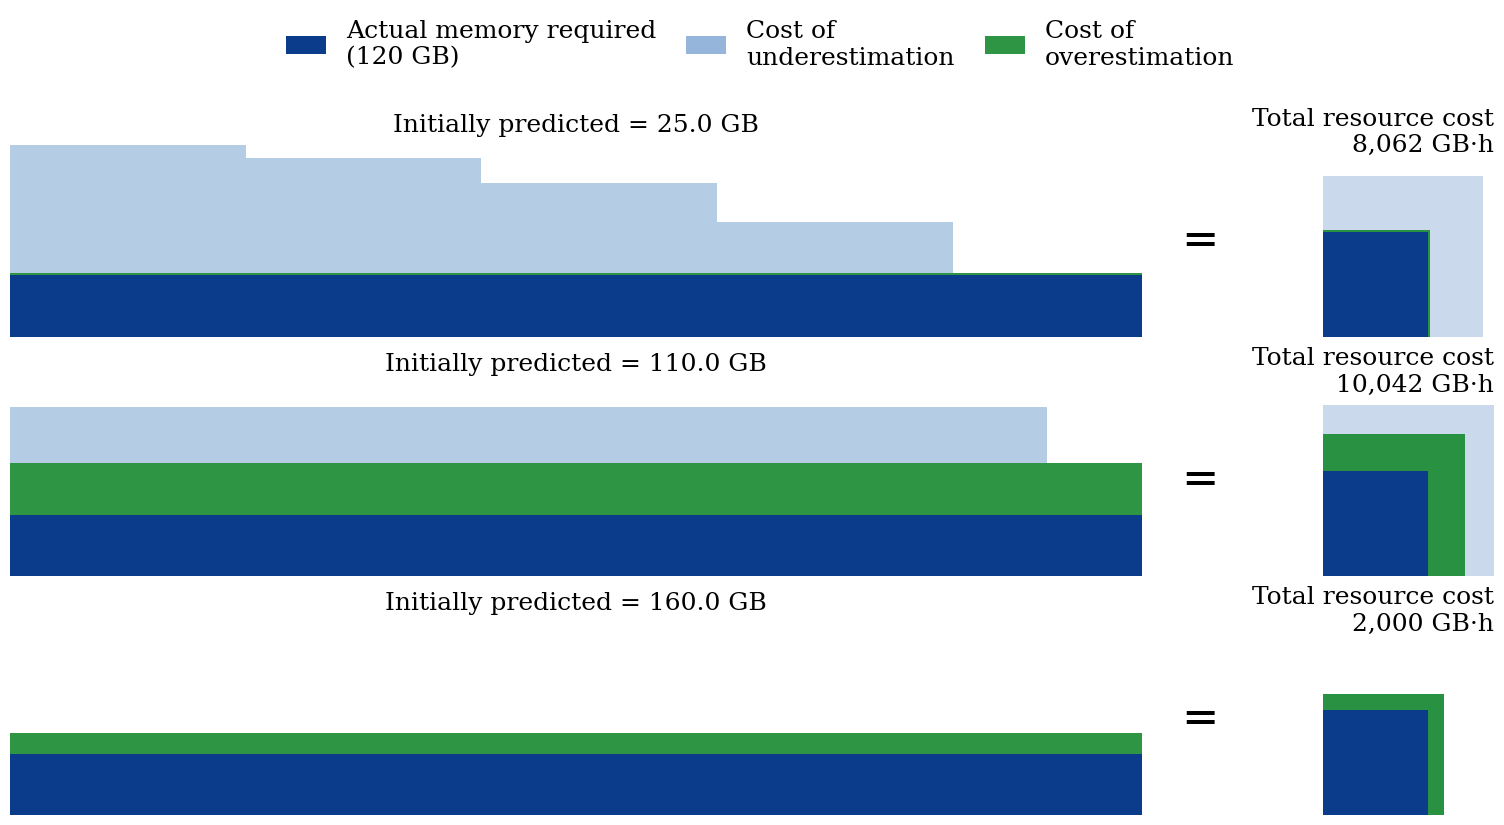

In [13]:
# ------------------ Global Style ------------------
BASE_FONTSIZE = 18
plt.rcParams.update({
    "font.size": BASE_FONTSIZE,
    "axes.titlesize": BASE_FONTSIZE,
    "legend.fontsize": BASE_FONTSIZE,
    "font.family": "serif",
    "axes.linewidth": 1.5
})

def kill_axes(ax):
    ax.set_xticks([])
    ax.set_yticks([])
    for side in ("left", "right", "top", "bottom"):
        ax.spines[side].set_visible(False)

# ------------------ Gather results ------------------
runs = []
max_job_width = 0.0
max_total_height = 0.0
max_outer_side = 0.0

inner_side = np.sqrt(y_true * true_wall_time)

for a0 in allocations:
    result = JobCost.job_cost(y_true, true_wall_time, dummy_policy, a0)
    runs.append((a0, result))

    max_job_width = max(
        max_job_width,
        max([w for w, _ in result["failed_alloc_time"]] + [true_wall_time])
    )

    total_h = sum(h for _, h in result["failed_alloc_time"]) + result["a_R"]
    max_total_height = max(max_total_height, total_h)

    max_outer_side = max(
        max_outer_side,
        np.sqrt(result["total_mem_rate"])
    )

# ------------------ Layout ------------------
n = len(runs)
fig = plt.figure(figsize=(20.0, 2.9 * n))

gs = fig.add_gridspec(
    nrows=n,
    ncols=3,
    width_ratios=[4.3, 0.25, 1.15],
    wspace=0.05,
    hspace=0.25
)

# Colors
COLOR_ACTUAL = "#0b3c8c"
COLOR_UNDER = "#2c6fb7"
COLOR_OVER = "#178a2f"

# ------------------ Plot ------------------
for i, (a0, result) in enumerate(runs):
    axL = fig.add_subplot(gs[i, 0])
    axE = fig.add_subplot(gs[i, 1])
    axR = fig.add_subplot(gs[i, 2])

    total_h = sum(h for _, h in result["failed_alloc_time"]) + result["a_R"]
    y_top = total_h

    # -------- LEFT: Timeline --------
    for w, h in result["failed_alloc_time"]:
        y_top -= h
        axL.add_patch(Rectangle(
            (0, y_top), w, h,
            facecolor=COLOR_UNDER,
            alpha=0.35
        ))

    axL.add_patch(Rectangle(
        (0, 0), true_wall_time, y_true,
        facecolor=COLOR_ACTUAL,
        alpha=1.0
    ))

    if result["a_R"] > y_true:
        axL.add_patch(Rectangle(
            (0, y_true),
            true_wall_time,
            result["a_R"] - y_true,
            facecolor=COLOR_OVER,
            alpha=0.9
        ))

    axL.set_xlim(0, max_job_width)
    axL.set_ylim(0, max_total_height)

    # ✔ Updated title
    axL.set_title(f"Initially predicted = {a0:.1f} GB", pad=10)

    kill_axes(axL)

    # -------- CENTER: Equal sign --------
    kill_axes(axE)
    axE.text(0.5, 0.5, "=", ha="center", va="center", fontsize=32)

    # -------- RIGHT: Area Squares --------
    outer_under = np.sqrt(result["total_mem_rate"])
    inner_actual = inner_side

    axR.add_patch(Rectangle(
        (0, 0),
        outer_under,
        outer_under,
        facecolor=COLOR_UNDER,
        alpha=0.25
    ))

    if result["a_R"] > y_true:
        over_side = np.sqrt(true_wall_time * result["a_R"])
        axR.add_patch(Rectangle(
            (0, 0),
            over_side,
            over_side,
            facecolor=COLOR_OVER,
            alpha=0.9
        ))

    axR.add_patch(Rectangle(
        (0, 0),
        inner_actual,
        inner_actual,
        facecolor=COLOR_ACTUAL,
        alpha=1.0
    ))

    axR.set_xlim(0, max_outer_side)

    # ✔ Add headroom for label
    axR.set_ylim(0, max_outer_side * 1.12)
    axR.set_aspect('equal')

    kill_axes(axR)

    # ✔ Updated label (top, aligned, clearer wording)
    axR.text(
        max_outer_side,
        max_outer_side * 1.05,
        f"Total resource cost\n{result['total_waste_rate']:,.0f} GB·h",
        ha="right",
        va="bottom",
        fontsize=BASE_FONTSIZE
    )

# ------------------ Legend ------------------
legend_elements = [
    Patch(
        facecolor=COLOR_ACTUAL,
        label=f"Actual memory required\n({y_true:.0f} GB)"
    ),
    Patch(
        facecolor=COLOR_UNDER,
        alpha=0.5,
        label="Cost of\nunderestimation"
    ),
    Patch(
        facecolor=COLOR_OVER,
        alpha=0.9,
        label="Cost of\noverestimation"
    )
]

fig.legend(
    handles=legend_elements,
    loc="upper center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 1.05),
    columnspacing=1.2,
    handlelength=1.6,
    handletextpad=0.8
)



plt.tight_layout(rect=(0, 0, 1, 0.92))

plt.savefig("../results/retry_example.svg", dpi=600, bbox_inches="tight")
plt.savefig("../results/retry_example.png", dpi=600, bbox_inches="tight")

plt.show()

---

## What the results show

When we compared all models using cost-based metrics—total memory usage waste, total wall time, and failure rate —based on real production distribution, the results changed.

In [14]:
erz_to_wall_time = dict(zip(mgnify_dataset["primary_accession"], mgnify_dataset["wall_clock_seconds"]))
training_df_wall_time = (np.array([erz_to_wall_time.get(err_to_erz.get(srr,"")) for srr in df.index]) / 60) / 60  # in hours

In [52]:

# --- 0) Prepare true wall time ---
erz_to_wall_time = dict(zip(mgnify_dataset["primary_accession"], mgnify_dataset["wall_clock_seconds"]))
training_df_wall_time = (np.array([erz_to_wall_time.get(err_to_erz.get(srr,"")) for srr in df.index]) / 60) / 60  # in hours

# --- 1) Prepare data ---
real_logs_peak_memory = mgnify_dataset["peak_mem_in_gbs"].to_numpy()
sample_true = y.to_numpy()
base_wall_time = training_df_wall_time
retry_policy = lambda R, a0: (R+1) * a0

keys = quant_results.keys()


# Use **all predictors from quant_results**, plus a Dummy predictor
predictors: Dict[str, np.ndarray] = {f"{x[0]} {x[1]}": quant_results[x] for x in keys}

# Add a naive "Dummy" predictor
# naive_mean = int(np.mean(real_logs_peak_memory))
# predictors[f"Dummy {naive_mean} GB"] = np.full_like(sample_true, naive_mean)

# Ensure no predictions are below 1GB
for k in predictors:
    predictors[k] = np.maximum(1.0, predictors[k])

# --- 2) Build evaluator ---
ev = HPCMemoryEvaluator(
    sample_peak_true=sample_true,
    pop_peak_true=real_logs_peak_memory,
    predictors=predictors,
    total_waste_fn=lambda mem_true, time_true, mem_pred: JobCost.batch_job_total_waste_rate(mem_true, time_true, retry_policy, mem_pred),
    total_wall_time_fn=lambda mem_true, time_true, mem_pred: JobCost.batch_job_total_time(mem_true, time_true, retry_policy, mem_pred),
    base_wall_time=base_wall_time,
    weighting_cfg=WeightingConfig(nbins=60, log_scale=True),
)

# --- 3) Run evaluation ---
ev.compute_importance_weights()
summary_df, draws = ev.evaluate(n_jobs=1000, n_iter=4000, seed=123)

# --- 4) Show results ---
print(summary_df.to_markdown(index=False))

| predictor                                             |   waste_per_1000_mean |   waste_per_1000_lo |   waste_per_1000_hi |   wall_per_1000_mean |   wall_per_1000_lo |   wall_per_1000_hi |   failure_rate_mean |   failure_rate_lo |   failure_rate_hi |
|:------------------------------------------------------|----------------------:|--------------------:|--------------------:|---------------------:|-------------------:|-------------------:|--------------------:|------------------:|------------------:|
| MGnify Heuristic default                              |           3.27223e+06 |         2.40421e+06 |         4.42224e+06 |              50122.5 |            37411.8 |            68395.3 |           0.0369615 |          0.026    |          0.049    |
| Galaxy Heuristic default                              |           9.02624e+06 |         7.68765e+06 |         1.07103e+07 |              38966   |            31795.3 |            48325.6 |           0         |          0        |         

# merge model and retry model performance into nice table

In [50]:
# Merge waste statistics into df_results
summary_tmp = summary_df.copy()
df_results_tmp = df_results.copy()

# add quantile to Gaussian Processes model names
gp_mask = df_results_tmp["Model"] == "Gaussian Processes"

df_results_tmp.loc[gp_mask, "Model"] = (
    df_results_tmp.loc[gp_mask, "Model"]
    + " (Quantile "
    + df_results_tmp.loc[gp_mask, "Quantile"].astype(str)
    + ")"
)

# merge statistics
df_results_tmp = df_results_tmp.merge(
    summary_tmp[
        [
            "predictor",
            "waste_per_1000_mean",
            "waste_per_1000_lo",
            "waste_per_1000_hi"
        ]
    ],
    left_on="raw_name",
    right_on="predictor",
    how="left"
)

# convert to Million GB·h
mean_val = df_results_tmp["waste_per_1000_mean"] / 1e6

# symmetric average error
err = (
    (
        (df_results_tmp["waste_per_1000_hi"] - df_results_tmp["waste_per_1000_mean"]) +
        (df_results_tmp["waste_per_1000_mean"] - df_results_tmp["waste_per_1000_lo"])
    ) / 2
) / 1e6

# combined metric
df_results_tmp["Waste per 1000 jobs (Million GB·h)"] = (
    mean_val.round(2).astype(str)
    + " ± "
    + err.round(2).astype(str)
)

# cleanup
df_results_tmp = df_results_tmp.drop(columns=[
    "predictor",
    "raw_name",
    "Quantile",
    "waste_per_1000_mean",
    "waste_per_1000_lo",
    "waste_per_1000_hi"
])

print(df_results_tmp)

# Save table
df_results_tmp.to_csv("../results/model_performance_retry.csv", index=False)

                                 Model                    Features         R²  \
0                        Random Forest  K-mers + File size + Biome   0.678518   
1                        Random Forest          K-mers + File size   0.648760   
2                        Random Forest                       Biome   0.466952   
3                     LinearRegression                       Biome   0.465481   
4    Gaussian Processes (Quantile 0.9)                       Biome   0.460242   
5   Gaussian Processes (Quantile 0.99)                       Biome   0.446941   
6                     LinearRegression  K-mers + File size + Biome   0.285872   
7    Gaussian Processes (Quantile 0.9)  K-mers + File size + Biome   0.212650   
8                     LinearRegression                   File size   0.178354   
9    Gaussian Processes (Quantile 0.9)          K-mers + File size   0.112958   
10                       Random Forest                   File size   0.023788   
11                    Linear

In [59]:
keys = [ ('MGnify Heuristic', 'default'), 
        ('Galaxy Heuristic', 'default'), 
        ('LinearRegression (File size)', 'default'), 
        ('Random Forest (Biome)', 'default'), 
        ('Random Forest (K-mers + File size)', 'default'), 
        ('Random Forest (K-mers + File size + Biome)', 'default'), 
        ("Gaussian Processes (Biome)", 0.99), 
        ("Gaussian Processes (K-mers + File size)", 0.99), 
        ("Gaussian Processes (K-mers + File size + Biome)", 0.99), ]

# build list of matching predictors
target_predictors = []

for model, q in keys:
    if q == "default":
        target_predictors.append(f"{model} default")
    else:
        target_predictors.append(f"{model} {q}")

# filter rows
filtered_summary = summary_df[
    summary_df["predictor"].isin(target_predictors)
].copy()

print(filtered_summary)

                                            predictor  waste_per_1000_mean  \
0                            MGnify Heuristic default         3.272231e+06   
1                            Galaxy Heuristic default         9.026239e+06   
2          Random Forest (K-mers + File size) default         3.169657e+06   
4   Random Forest (K-mers + File size + Biome) def...         3.201389e+06   
5                       Random Forest (Biome) default         2.451177e+06   
7                LinearRegression (File size) default         3.531004e+06   
14       Gaussian Processes (K-mers + File size) 0.99         2.883476e+06   
16                    Gaussian Processes (Biome) 0.99         2.883849e+06   
17  Gaussian Processes (K-mers + File size + Biome...         3.350320e+06   

    waste_per_1000_lo  waste_per_1000_hi  wall_per_1000_mean  \
0        2.404207e+06       4.422235e+06        50122.505079   
1        7.687646e+06       1.071025e+07        38965.973318   
2        1.931476e+06      

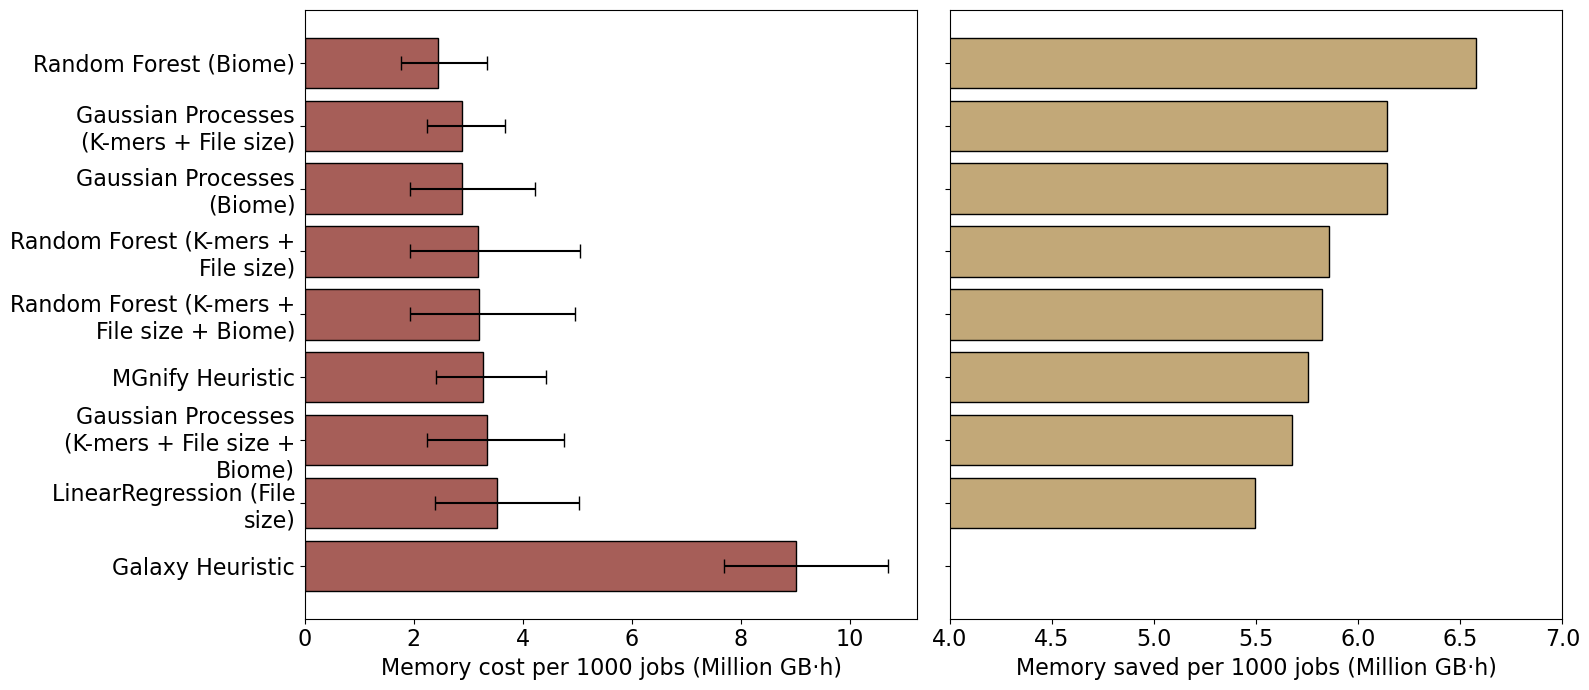

In [60]:

plt.rcdefaults()

# ------------------ Styling ------------------
LABEL_SIZE = 16
TICK_SIZE = 16
TITLE_SIZE = 16

WASTE_COLOR = "#A65E58"   # dusty rose
SAVE_COLOR  = "#C2A878"   # muted gold

# ------------------ Function to shorten/wrap labels ------------------
def shorten_label(label, width=25):
    parts = label.split()
    if len(parts) > 1:
        parts = parts[:-1]  # remove last word
    main_label = " ".join(parts)
    return "\n".join(textwrap.wrap(main_label, width))

# ------------------ Sort dataframe ------------------
summary_sorted = filtered_summary.sort_values(
    "waste_per_1000_mean",
    ascending=False
)

# ------------------ Symmetric error ------------------
error = [
    summary_sorted["waste_per_1000_mean"]
    - summary_sorted["waste_per_1000_lo"],

    summary_sorted["waste_per_1000_hi"]
    - summary_sorted["waste_per_1000_mean"]
]

# ------------------ Wrapped labels ------------------
labels = [
    shorten_label(l)
    for l in summary_sorted["predictor"]
]

# ------------------ Memory saved ------------------
highest_waste = summary_sorted["waste_per_1000_mean"].max()

saved_memory = (
    highest_waste
    - summary_sorted["waste_per_1000_mean"]
)

# ------------------ Figure ------------------
fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 7),
    sharey=True
)

# =========================================================
# LEFT PANEL
# =========================================================
axes[0].barh(
    labels,
    summary_sorted["waste_per_1000_mean"] / 1e6,
    xerr=[e / 1e6 for e in error],
    capsize=5,
    color=WASTE_COLOR,
    edgecolor="black"
)

axes[0].invert_yaxis()

axes[0].set_xlabel(
    "Memory cost per 1000 jobs (Million GB·h)",
    fontsize=LABEL_SIZE
)

# axes[0].set_title(
#     "Predicted memory cost per 1000 jobs",
#     fontsize=TITLE_SIZE
# )

# =========================================================
# RIGHT PANEL
# =========================================================
axes[1].barh(
    labels,
    saved_memory / 1e6,
    color=SAVE_COLOR,
    edgecolor="black"
)

axes[1].invert_yaxis()

axes[1].set_xlabel(
    "Memory saved per 1000 jobs (Million GB·h)",
    fontsize=LABEL_SIZE
)

# axes[1].set_title(
#     f"Memory saved relative to highest predictor\n({highest_waste/1e6:.2f} Million GB·h)",
#     fontsize=TITLE_SIZE
# )

axes[1].set_xlim(4, 7)

# =========================================================
# Tick label sizes
# =========================================================
for ax in axes:
    ax.tick_params(
        axis='both',
        labelsize=TICK_SIZE
    )

# =========================================================
# Layout + Export
# =========================================================
plt.tight_layout()

plt.savefig(
    "../results/waste_memory_side_by_side.svg",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "../results/waste_memory_side_by_side.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

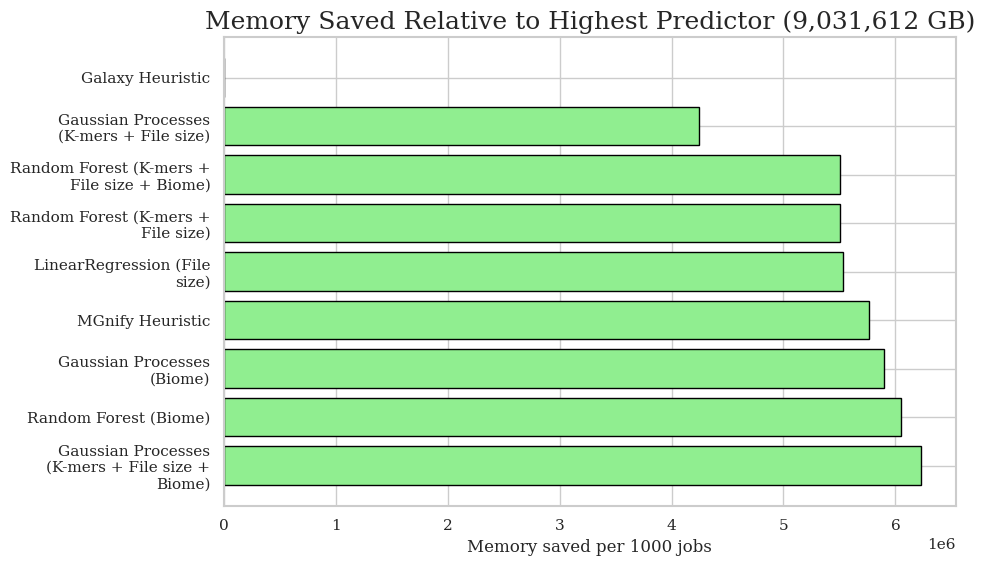

In [34]:
# --- Second plot: Memory saved relative to highest predictor ---
highest_waste = summary_sorted["waste_per_1000_mean"].max()
saved_memory = highest_waste - summary_sorted["waste_per_1000_mean"]

plt.figure(figsize=(10, 6))
plt.barh(
    labels,
    saved_memory,
    color="lightgreen",
    edgecolor="black"
)
plt.xlabel("Memory saved per 1000 jobs")
plt.title(f"Memory Saved Relative to Highest Predictor ({highest_waste:,.0f} GB)")
plt.gca().invert_yaxis()  # Keep same order as original chart
plt.tight_layout()
plt.show()

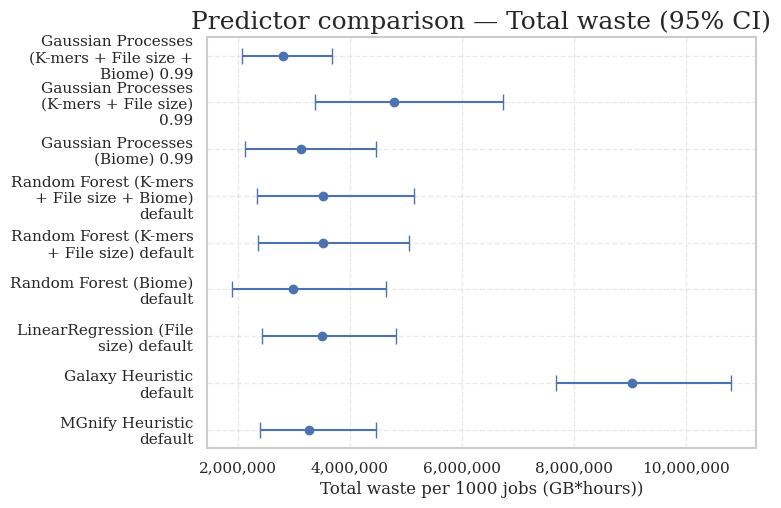

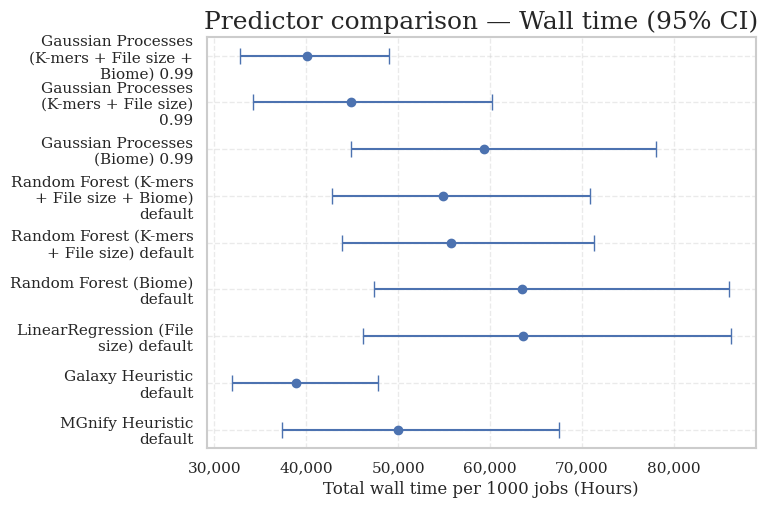

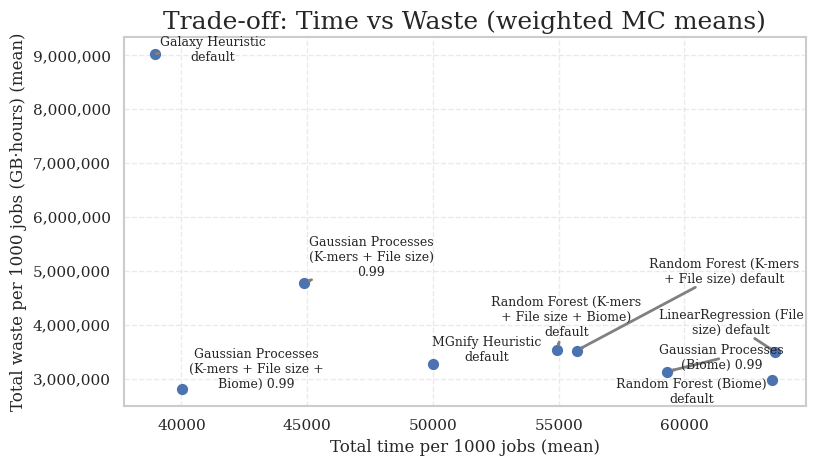

In [25]:

# Optional plots (require matplotlib)
ev.plot_errorbars(metric="waste")
ev.plot_errorbars(metric="wall")
# ev.plot_weighted_density(metric="waste", bins=50)
#ev.plot_mc_distribution(metric="waste", bins=40)
ev.plot_tradeoff()


# Get formular of Linear Regression model trained on all data to add rule to TPV

In [ ]:
from sklearn.linear_model import LinearRegression
import pandas as pd

# Features: only file_size
X = stats[["file_size"]] / 1024**3
y = y  # your target series

# Train on all data
lr = LinearRegression()
lr.fit(X, y)

# Extract coefficients
intercept = lr.intercept_
slope = lr.coef_[0]

print(f"Linear Regression formula trained on all data:")
print(f"y = {intercept} + {slope} * file_size")
# add to TPV: https://github.com/galaxyproject/tpv-shared-database/pull/108

Linear Regression formula trained on all data:
y = 25.284994297063335 + 13.219421046263273 * file_size


In [16]:
import numpy as np
import pandas as pd
from typing import Optional, Tuple

# Fixed Galaxy heuristic (returns memory only)
def galaxy_metaspades_heuristic(input_size: float) -> Optional[int]:
    """
    Heuristic predictor for Galaxy MetaSPAdes tool.

    Parameters
    ----------
    input_size : float
        Size of the input data in bytes.

    Returns
    -------
    mem : int or None
        Memory in GB to allocate.
    """
    # Convert bytes → GB
    input_gb = input_size / 1024**3

    if input_gb < 1:
        mem = 100
    else:
        mem = 350

    return mem

# 1) Linear regression prediction
X_all = stats[["file_size"]]
y_pred_lr = lr.predict(X_all)  # your linear regression model

# 2) Galaxy heuristic prediction
galaxy_allocations = [galaxy_metaspades_heuristic(size) for size in stats["file_size"]]

# 3) Combine results for comparison
comparison_df = pd.DataFrame({
    "file_size": stats["file_size"],
    "LR_prediction": y_pred_lr,
    "Galaxy_heuristic": galaxy_allocations
}, index=stats.index)

print(comparison_df.head(10))

              file_size  LR_prediction  Galaxy_heuristic
ERR9581643   3295915885      65.862812               350
SRR21856512  4179152943      76.736825               350
SRR21856491  5408817563      91.875896               350
SRR21856508  4226492791      77.319652               350
SRR21856496  4930425317      85.986149               350
SRR21856489  4393417282      79.374750               350
SRR21856514  2013098427      50.069347               350
SRR21856497  4054590470      75.203268               350
SRR21856505  4344613778      78.773903               350
SRR21856503  3525793496      68.692960               350


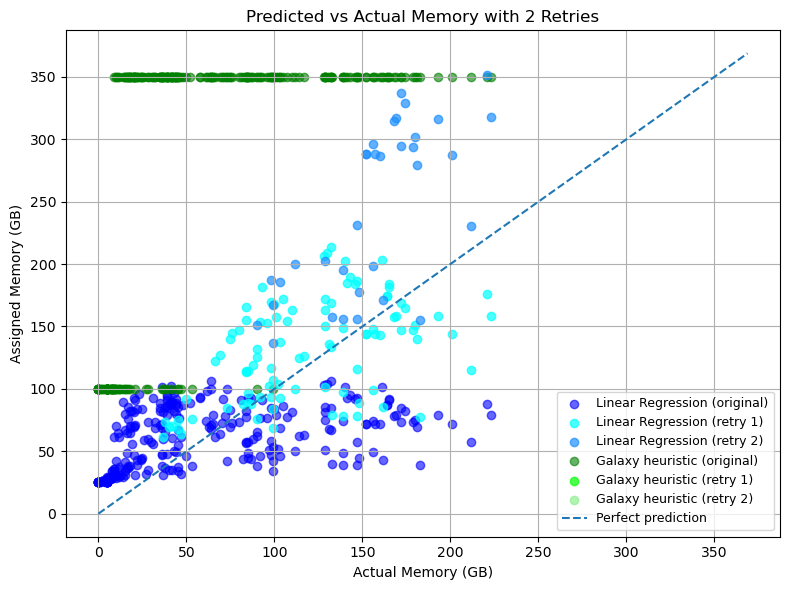

In [42]:
import matplotlib.pyplot as plt
import numpy as np

# Copy predictions
lr_pred = comparison_df["LR_prediction"].copy()
galaxy_pred = comparison_df["Galaxy_heuristic"].copy()

# Initialize retry predictions
lr_retry = lr_pred.copy()
galaxy_retry = galaxy_pred.copy()

# Colors: original + 2 retries
lr_colors = ["blue", "cyan", "dodgerblue"]
galaxy_colors = ["green", "lime", "lightgreen"]

plt.figure(figsize=(8,6))

handles = []
labels = []

# Original predictions
h1 = plt.scatter(y, lr_retry, alpha=0.6, color=lr_colors[0])
h2 = plt.scatter(y, galaxy_retry, alpha=0.6, color=galaxy_colors[0])

handles += [h1, h2]
labels += ["Linear Regression (original)", "Galaxy heuristic (original)"]

# Perform 2 retries
for retry in range(1, 3):
    # Linear Regression
    failed_lr = lr_retry < y
    lr_retry[failed_lr] = lr_retry[failed_lr] * 2
    h_lr = plt.scatter(y[failed_lr], lr_retry[failed_lr],
                       alpha=0.7, color=lr_colors[retry])

    # Galaxy heuristic
    failed_galaxy = galaxy_retry < y
    galaxy_retry[failed_galaxy] = galaxy_retry[failed_galaxy] * 2
    h_gal = plt.scatter(y[failed_galaxy], galaxy_retry[failed_galaxy],
                        alpha=0.7, color=galaxy_colors[retry])

    handles += [h_lr, h_gal]
    labels += [f"Linear Regression (retry {retry})", f"Galaxy heuristic (retry {retry})"]

# 1:1 reference line
max_val = max(y.max(), lr_retry.max(), galaxy_retry.max()) * 1.05
h_line, = plt.plot([0, max_val], [0, max_val], linestyle="--")
handles.append(h_line)
labels.append("Perfect prediction")

# Sort legend
order = sorted(range(len(labels)), key=lambda i: (
    0 if "Linear Regression" in labels[i] else 1,
    0 if "original" in labels[i] else int(labels[i].split("retry ")[1].split(")")[0]) if "retry" in labels[i] else 99
))

handles = [handles[i] for i in order]
labels = [labels[i] for i in order]

plt.xlabel("Actual Memory (GB)")
plt.ylabel("Assigned Memory (GB)")
plt.title("Predicted vs Actual Memory with 2 Retries")
plt.legend(handles, labels, fontsize=9)
plt.grid(True)
plt.tight_layout()


plt.savefig("../results/linear_vs_gheuristic.svg", dpi=600, bbox_inches="tight")
plt.savefig("../results/linear_vs_gheuristic.png", dpi=600, bbox_inches="tight")

plt.show()